In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 

import os
os.chdir(r'C:\Users\Lenovo\Desktop\Diabetes_Classifier\notebooks')
os.chdir("..")
print(os.getcwd())

from src.data_visualization import *


C:\Users\Lenovo\Desktop\Diabetes_Classifier


In [4]:
pd.set_option('display.max_columns',None)
df=pd.read_csv("data/clean/Diabetes Classifier Clean.csv")
df['diabetes_label'] = df['diagnosis'].map({0: 'no diabetes', 1: 'diabetes'})
total = len(df)

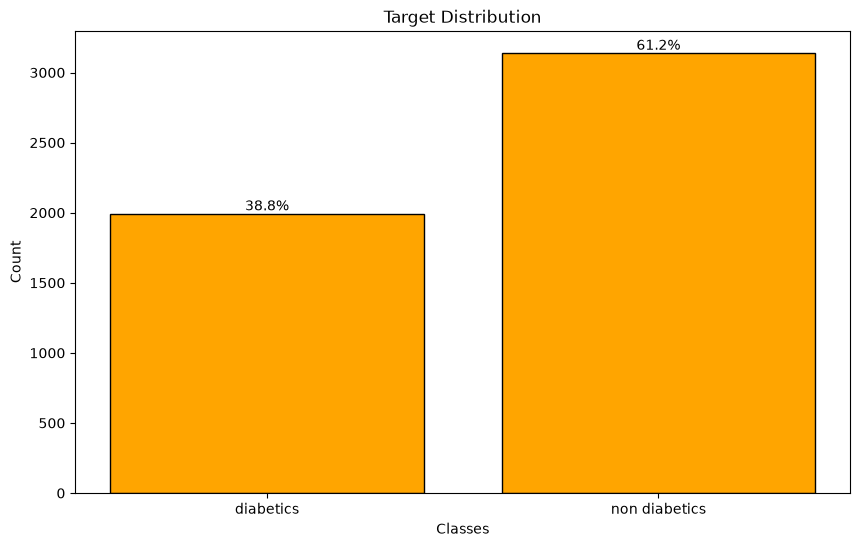

In [5]:
fig,ax=plt.subplots(figsize=(10,6))
diabetics=(df['diagnosis']==1).sum()
nonDiabetics=(df['diagnosis']==0).sum()

classes=['diabetics','non diabetics']
count=[diabetics,nonDiabetics]

plt.bar(classes,count,color='orange',edgecolor='black')
labeler(total,ax)
plt.title("Target Distribution")
plt.ylabel("Count")
plt.xlabel("Classes")
plt.show()


We can see that the target is very well distributed ~40/~60

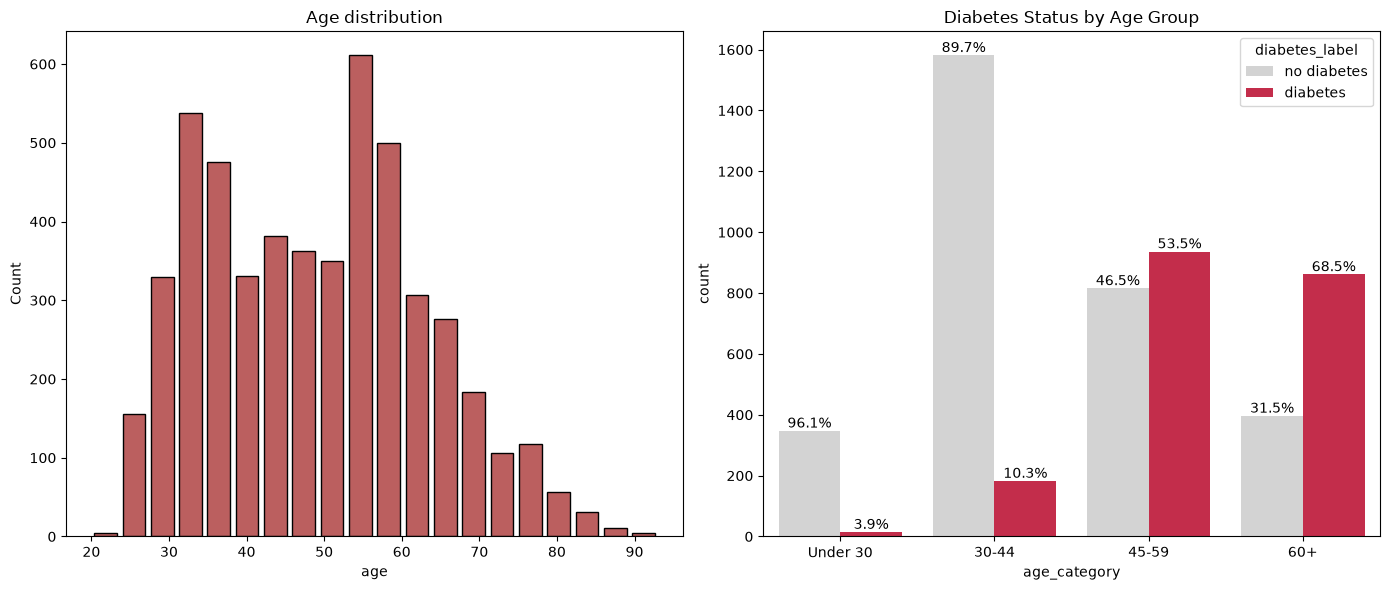

In [6]:

df['age_category'] = df['age'].apply(age_category)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(df['age'],bins=20,shrink=0.8, edgecolor='black',color='brown', ax=axes[0])
axes[0].set_title('Age distribution')

order_age = ["Under 30","30-44","45-59","60+"]
sns.countplot(data=df, x='age_category', hue='diabetes_label', order=order_age,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[1])
grouped_labeler(axes[1], df, 'age_category', order_age)
axes[1].set_title('Diabetes Status by Age Group')

plt.tight_layout()
plt.show()

We notice a trend, with age the risk of diabetes rises!

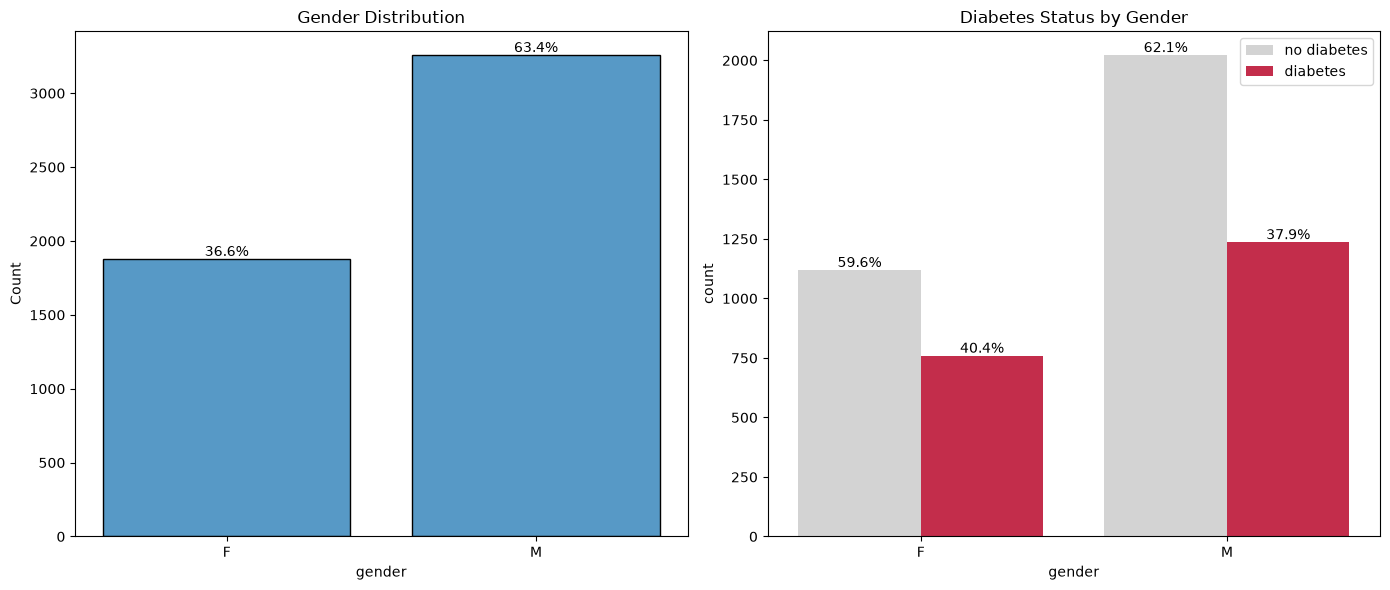

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))


sns.histplot(df['gender'], bins=2, shrink=0.8, edgecolor='black', ax=axes[0])
labeler(total, axes[0])
axes[0].set_title('Gender Distribution')


order = ['F','M']
sns.countplot(data=df, x='gender', hue='diabetes_label', order=order,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[1])
grouped_labeler(axes[1], df, 'gender', order)
axes[1].set_title('Diabetes Status by Gender')
axes[1].legend(title='')

plt.tight_layout()
plt.show()


Males tend to dominate this datase with 63% and Females are 36 %, but ~3% difference between Males affected with diabetes and Females in this dataset!

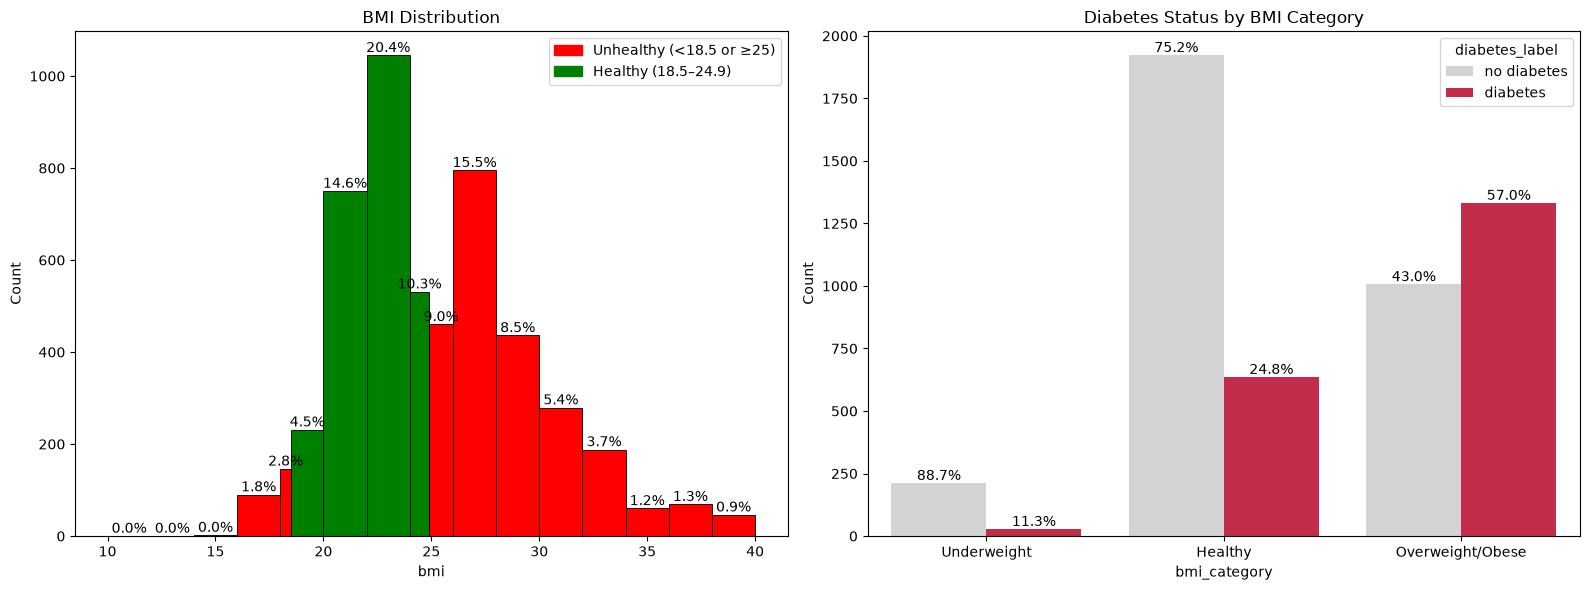

In [8]:
df['bmi_category'] = df['bmi'].apply(bmi_category)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
bins = [10,12,14,16,18,18.5,20,22,24,24.9,26,28,30,32,34,36,38,40]  

sns.histplot(df['bmi'], bins=bins, ax=axes[0])
labeler(total, axes[0])

for patch in axes[0].patches:
    x_start = patch.get_x()
    if x_start < 18.5:
        patch.set_facecolor('red')
    elif x_start < 24.9:
        patch.set_facecolor('green')
    else:
        patch.set_facecolor('red')

legend_patches = [
    mpatches.Patch(color='red', label='Unhealthy (<18.5 or ≥25)'),
    mpatches.Patch(color='green', label='Healthy (18.5–24.9)')
]
axes[0].legend(handles=legend_patches)
axes[0].set_title('BMI Distribution')

order = ['Underweight','Healthy','Overweight/Obese']
sns.countplot(data=df, x='bmi_category', hue='diabetes_label', order=order,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[1])
grouped_labeler(axes[1],df,'bmi_category',order)
axes[1].set_title('Diabetes Status by BMI Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


A trend we can notice here is that Obese/Overweight people with BMI over 25 are most likely to get diabetes with 57% of them being diabetics, its more than double of people being in the healthy category which were 24.8% affected by diabetes!

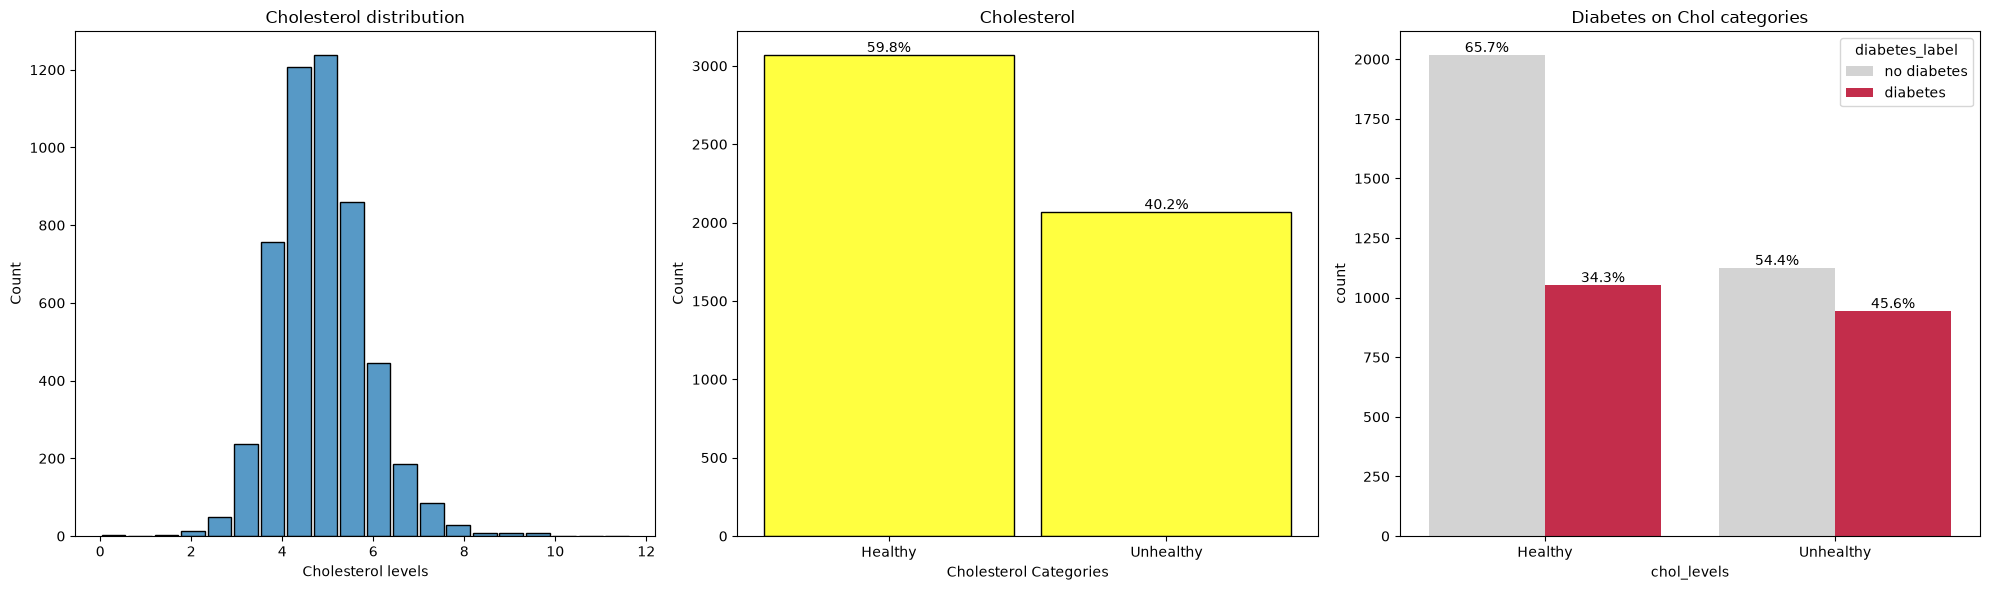

In [9]:
df['chol_levels']=df['chol'].apply(cholesterol)

fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(data=df['chol'],bins=20,shrink=0.9,edgecolor='black', ax=axes[0])
axes[0].set_xlabel("Cholesterol levels")
axes[0].set_ylabel("Count")
axes[0].set_title("Cholesterol distribution")

sns.histplot(data=df['chol_levels'],bins=2,color='yellow',edgecolor='black',shrink=0.9, ax=axes[1])
labeler(total,axes[1])
axes[1].set_xlabel("Cholesterol Categories")
axes[1].set_ylabel("Count")
axes[1].set_title("Cholesterol")

order=['Healthy','Unhealthy']
sns.countplot(data=df,x="chol_levels",hue='diabetes_label', order=order,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[2])
grouped_labeler(axes[2],df,'chol_levels',order)
axes[2].set_title("Diabetes on Chol categories")

plt.tight_layout()
plt.show()


We can see that Cholesterol is well distributed, ~60/40  healthy to unhealthy ratio. People with unhealthy cholesterol levels tend to have diabetes 10% more than people with healthy levels of cholesterol.

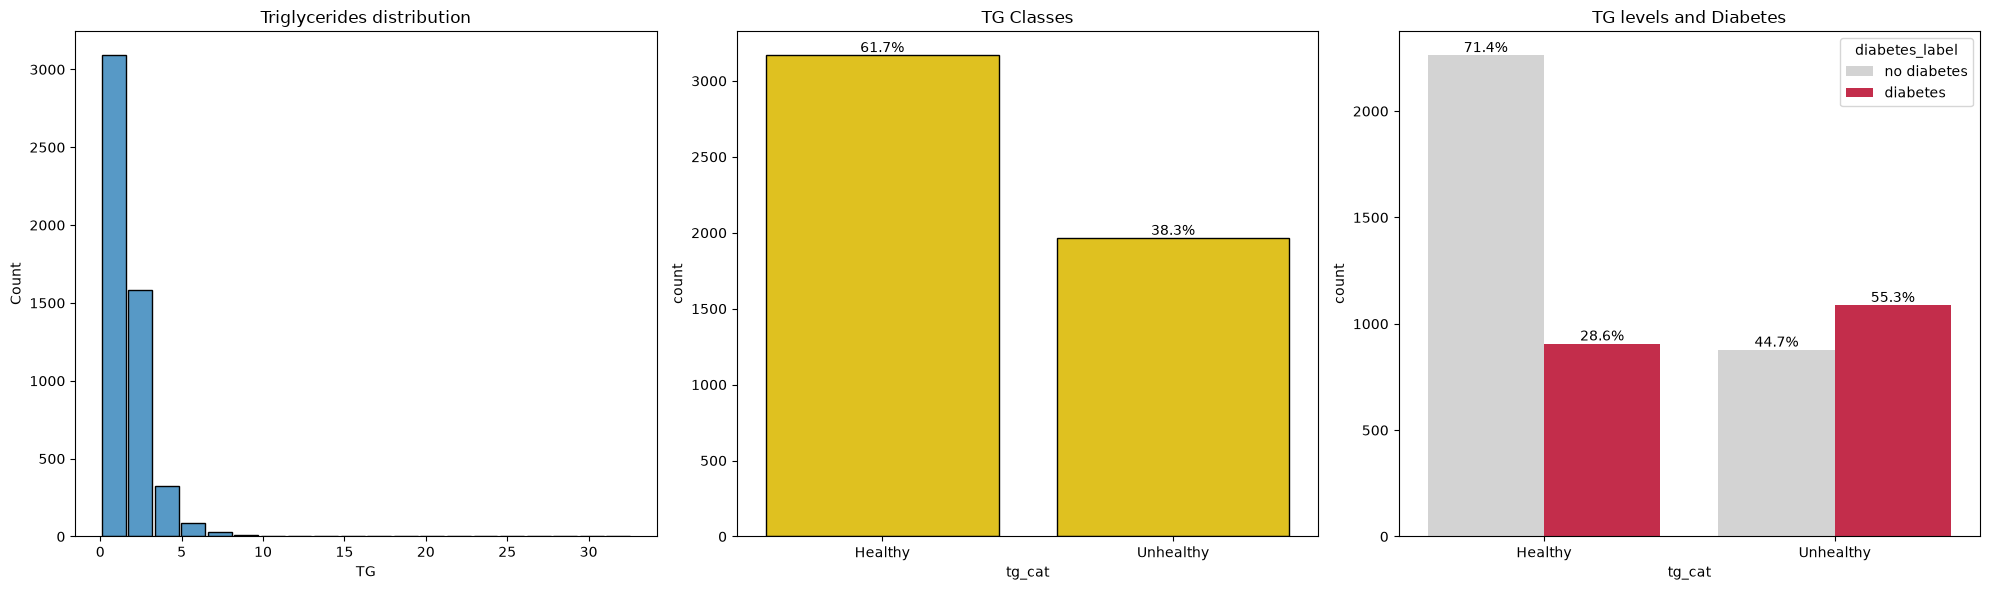

In [10]:
df['tg_cat']=df['tg'].apply(tg_category)
fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(data=df['tg'],bins=20,shrink=0.9,edgecolor='black', ax=axes[0])
axes[0].set_xlabel("TG")
axes[0].set_ylabel("Count")
axes[0].set_title("Triglycerides distribution")

order_tg=["Healthy","Unhealthy"]
sns.countplot(data=df,x="tg_cat", order=order_tg, color='gold', edgecolor='black', ax=axes[1])
labeler(total, axes[1])
axes[1].set_title("TG Classes")

sns.countplot(data=df,x="tg_cat",hue='diabetes_label', order=order_tg,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[2])
grouped_labeler(axes[2],df,'tg_cat',order_tg)
axes[2].set_title("TG levels and Diabetes")

plt.tight_layout()
plt.show()


Triglycerides are again decently distributed ~60/40 healthy to unhealthy ration but a significant amount of unhealthy people -55.3% of them have diabetes while only 28.6% of the people with healthy levels have diabetes.

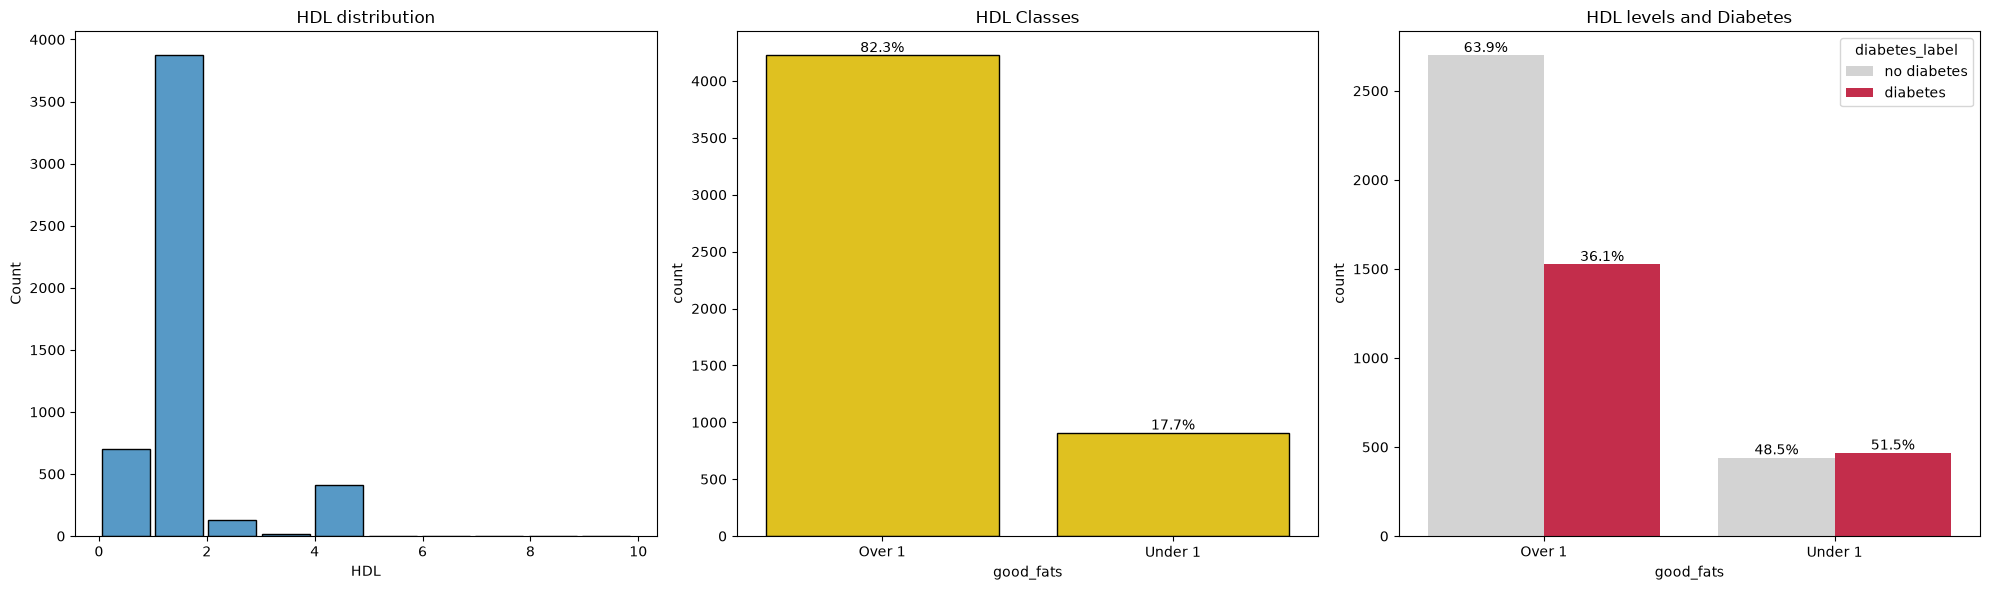

In [11]:
df['good_fats']=df['hdl'].apply(goodFats)
fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(data=df['hdl'],bins=10,shrink=0.9,edgecolor='black', ax=axes[0])
axes[0].set_xlabel("HDL")
axes[0].set_ylabel("Count")
axes[0].set_title("HDL distribution")

order_hdl=["Over 1","Under 1"]
sns.countplot(data=df,x="good_fats", order=order_hdl, color='gold', edgecolor='black', ax=axes[1])
labeler(total, axes[1])
axes[1].set_title("HDL Classes")

sns.countplot(data=df,x="good_fats",hue='diabetes_label', order=order_hdl,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[2])
grouped_labeler(axes[2],df,'good_fats',order_hdl)
axes[2].set_title("HDL levels and Diabetes")

plt.tight_layout()
plt.show()


The HDL(high density lipids) distribution is ~82/18 with people being split with hdl over or under 1, over 1 being healthy and under 1 being unhealthy, ~52% of people that have hdl under 1 are diabetics while only 36% of the people that have hdl over 1 have diabetes! 

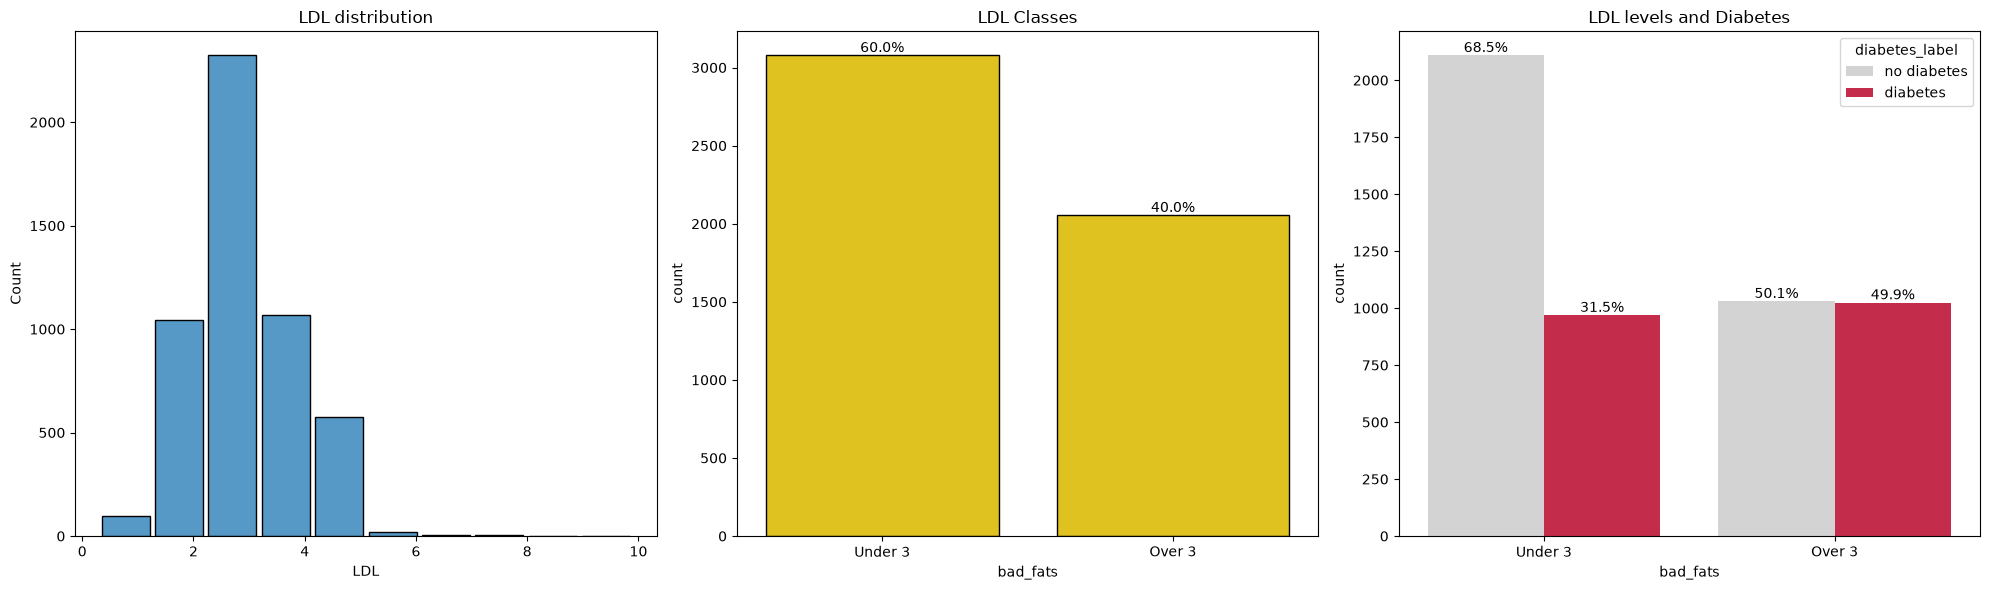

In [12]:
df['bad_fats']=df['ldl'].apply(badFats)
fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(data=df['ldl'],bins=10,shrink=0.9,edgecolor='black', ax=axes[0])
axes[0].set_xlabel("LDL")
axes[0].set_ylabel("Count")
axes[0].set_title("LDL distribution")

order_ldl=["Under 3","Over 3"]
sns.countplot(data=df,x="bad_fats", order=order_ldl, color='gold', edgecolor='black', ax=axes[1])
labeler(total, axes[1])
axes[1].set_title("LDL Classes")

sns.countplot(data=df,x="bad_fats",hue='diabetes_label', order=order_ldl,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[2])
grouped_labeler(axes[2],df,'bad_fats',order_ldl)
axes[2].set_title("LDL levels and Diabetes")

plt.tight_layout()
plt.show()

LDL(low density lipids) are well distributed 60/40 healthy to unhealthy ration, ~50% of people that ldl levels is over 3 (unhealthy) are diabetics while only 31.5% of people with ldl levels under 3 are diabetics! 

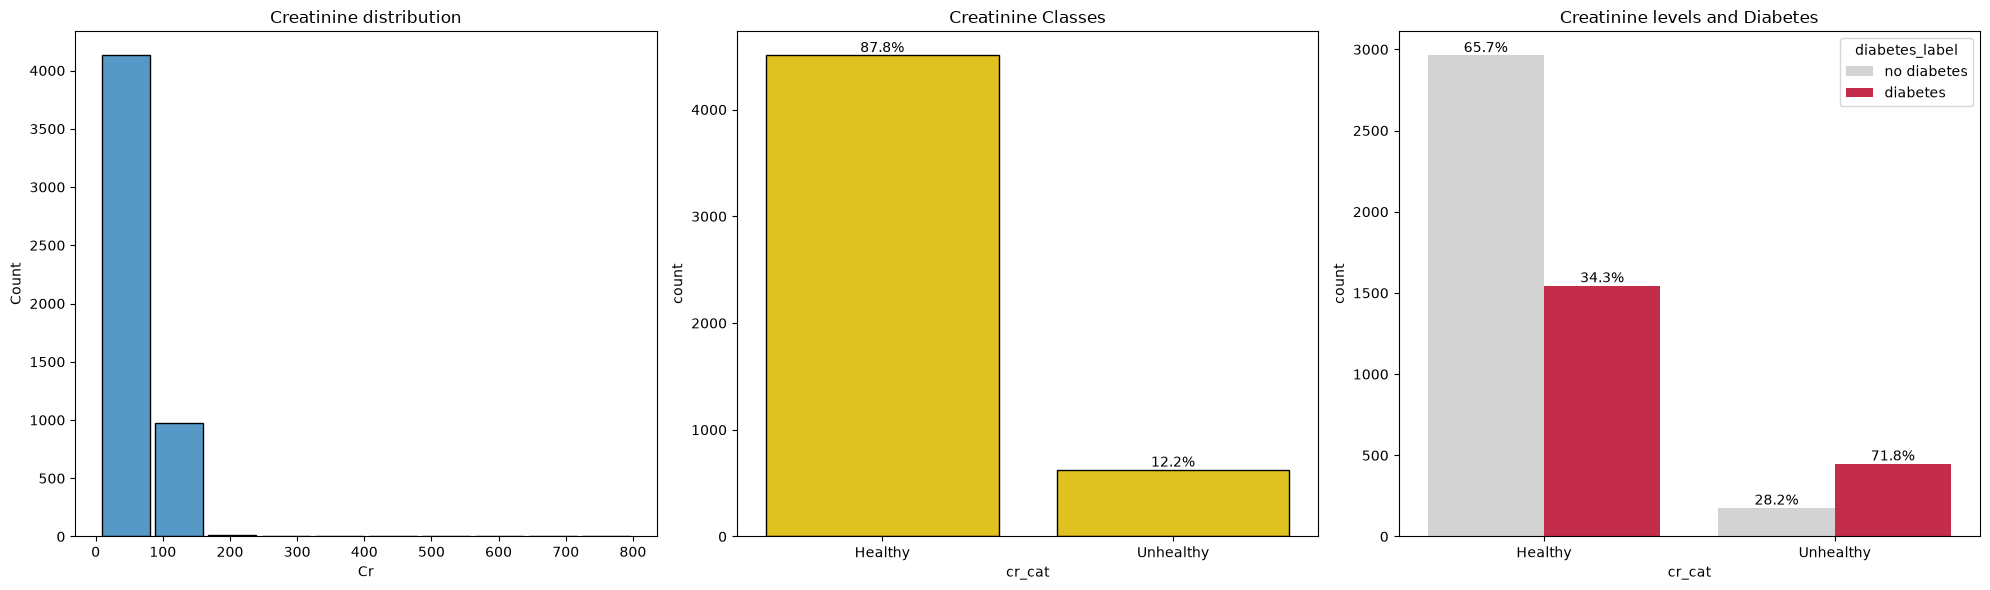

In [13]:
df['cr_cat']=df.apply(creatinine,axis=1)
fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(data=df['cr'],bins=10,shrink=0.9,edgecolor='black', ax=axes[0])
axes[0].set_xlabel("Cr")
axes[0].set_ylabel("Count")
axes[0].set_title("Creatinine distribution")

order_cr=["Healthy","Unhealthy"]
sns.countplot(data=df,x="cr_cat", order=order_cr, color='gold', edgecolor='black', ax=axes[1])
labeler(total, axes[1])
axes[1].set_title("Creatinine Classes")

sns.countplot(data=df,x="cr_cat",hue='diabetes_label', order=order_cr,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[2])
grouped_labeler(axes[2],df,'cr_cat',order_cr)
axes[2].set_title("Creatinine levels and Diabetes")

plt.tight_layout()
plt.show()


Creatinine distribution is ~87/12 % Healthy to Unhealthy ratio taken into consideration gender differences on creatinine levels, ~34% of people with healthy levels of creatinine have diabetes and ~71% of the poeple with unhealthy levels have diabetes!

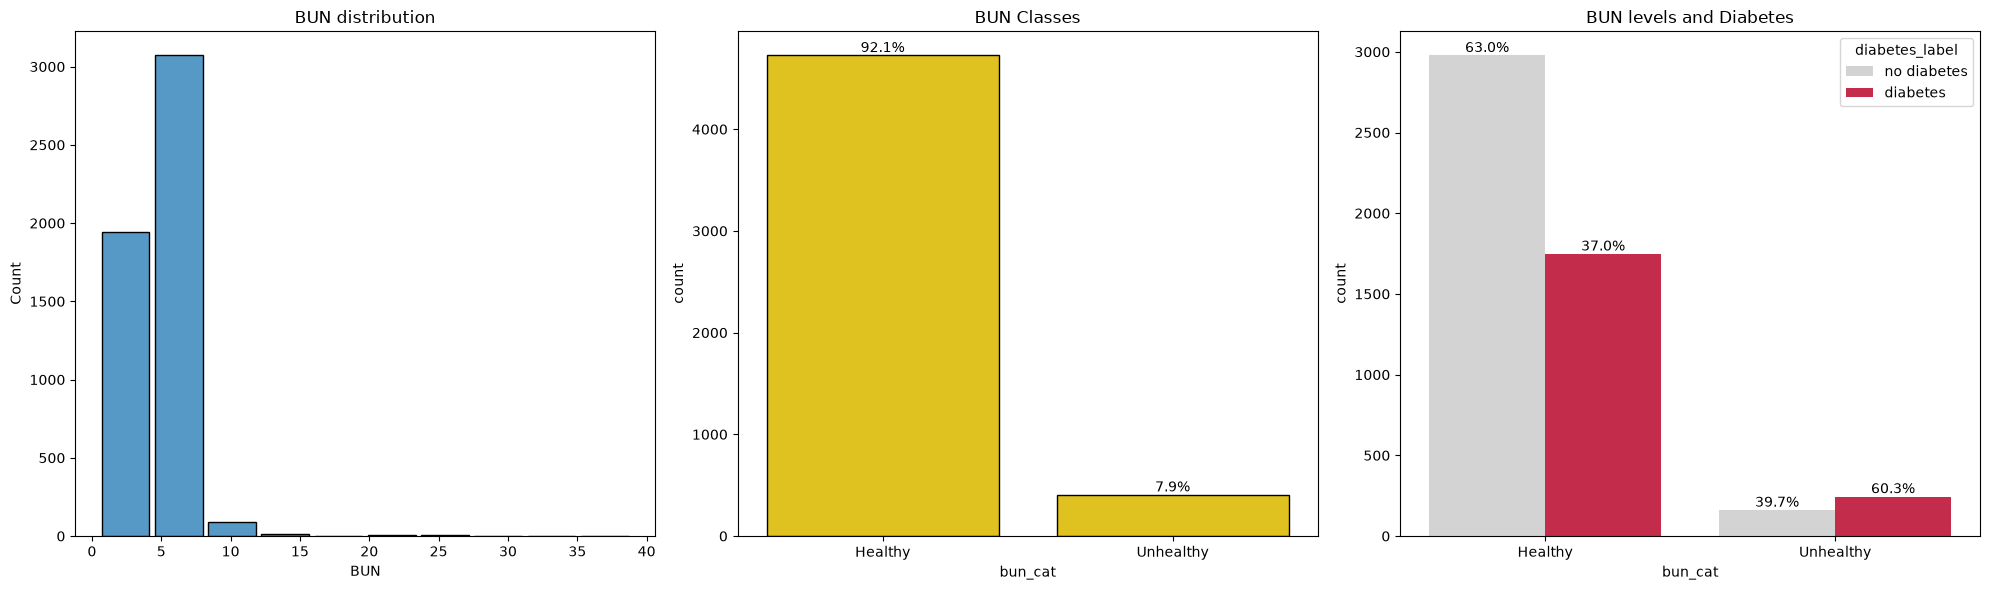

In [14]:
df['bun_cat']=df.apply(bun,axis=1)

fig, axes = plt.subplots(1, 3, figsize=(20,6))

sns.histplot(data=df['bun'],bins=10,shrink=0.9,edgecolor='black', ax=axes[0])
axes[0].set_xlabel("BUN")
axes[0].set_ylabel("Count")
axes[0].set_title("BUN distribution")

order_bun=["Healthy","Unhealthy"]
sns.countplot(data=df,x="bun_cat", order=order_bun, color='gold', edgecolor='black', ax=axes[1])
labeler(total, axes[1])
axes[1].set_title("BUN Classes")

sns.countplot(data=df,x="bun_cat",hue='diabetes_label', order=order_bun,
              palette={'no diabetes':'lightgray', 'diabetes':'crimson'}, ax=axes[2])
grouped_labeler(axes[2],df,'bun_cat',order_bun)
axes[2].set_title("BUN levels and Diabetes")

plt.tight_layout()
plt.show()


BUN(blood urea nitrogen) distribution is ~92/8 % Healthy to Unhealthy ration, with 60% of the unhealthy being diabetics and 37% of the healthy people being diabetics!

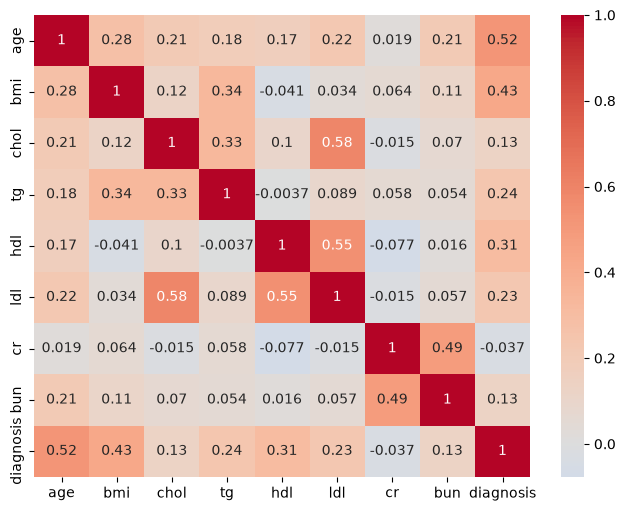

In [15]:
corr = df.drop(columns="gender").corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            center=0)
plt.show()

As we have seen until now, most correlation between features and target are age, bmi, hdl, ldl and tg as expected! We can also see high correlation between features chol-ldl, hdl-ldl,bmi-tg while cr has negative correlation with the target, hdl and ldl but high corelation with bun!